In [4]:
pip install pandas numpy matplotlib seaborn scikit-learn openpyxl

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

In [6]:
df = pd.read_excel("textile_customer_dataset.xlsx")

In [7]:
df.head()

,Customer_ID,Age,Gender,Purchase_Frequency,Total_Purchases,Total_Amount,Average_Purchase,Shirts,Sarees,Pants,Kids_Wear,Dress_Materials,Discount_Count,Return_Count,Days_Since_Purchase,Preferred_Category,Membership,Payment_Method
0,C00001,28.0,Male,8.0,19.0,40448.52,2128.87,5.0,8.0,1.0,2.0,3.0,3.0,0.0,119.0,Sarees,Regular,UPI
1,C00002,18.0,Male,9.0,20.0,39472.85,1973.64,3.0,3.0,0.0,12.0,2.0,3.0,1.0,72.0,Kids Wear,NaN,UPI
2,C00003,30.0,Female,2.0,4.0,6307.48,1576.87,0.0,2.0,0.0,2.0,0.0,3.0,1.0,165.0,Sarees,Regular,Cash
3,C00004,46.0,Male,5.0,7.0,7988.91,1141.27,1.0,4.0,0.0,1.0,1.0,9.0,1.0,68.0,Sarees,Silver,UPI
4,C00005,41.0,Male,5.0,10.0,18123.68,1812.37,4.0,2.0,1.0,2.0,1.0,2.0,1.0,34.0,Sarees,NaN,UPI


In [8]:
df.shape

(1048575, 18)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 18 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Customer_ID          500 non-null    object 
 1   Age                  501 non-null    float64
 2   Gender               500 non-null    object 
 3   Purchase_Frequency   500 non-null    float64
 4   Total_Purchases      500 non-null    float64
 5   Total_Amount         502 non-null    float64
 6   Average_Purchase     502 non-null    float64
 7   Shirts               500 non-null    float64
 8   Sarees               500 non-null    float64
 9   Pants                500 non-null    float64
 10  Kids_Wear            500 non-null    float64
 11  Dress_Materials      500 non-null    float64
 12  Discount_Count       500 non-null    float64
 13  Return_Count         500 non-null    float64
 14  Days_Since_Purchase  500 non-null    float64
 15  Preferred_Category   500 non-nul

In [10]:
df.describe()

,Age,Purchase_Frequency,Total_Purchases,Total_Amount,Average_Purchase,Shirts,Sarees,Pants,Kids_Wear,Dress_Materials,Discount_Count,Return_Count,Days_Since_Purchase
count,501.000000,500.000000,500.000000,502.000000,502.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,34.474000,9.400000,19.398000,42316.384080,1956.650320,4.366000,5.57400,3.292000,3.466000,2.700000,4.258000,0.646000,92.560000
std,10.940627,5.126066,11.578589,39264.641929,792.511656,3.058554,4.72792,2.579155,3.516472,2.348837,3.036095,0.816098,71.137891
min,18.000000,1.000000,1.000000,1371.710000,456.370000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
25%,26.000000,5.000000,10.000000,15531.315000,1385.450000,2.000000,2.00000,1.000000,1.000000,1.000000,2.000000,0.000000,41.750000
50%,34.000000,9.000000,18.000000,30972.140000,1855.625000,4.000000,4.00000,3.000000,2.000000,2.000000,4.000000,0.000000,74.000000
75%,41.000000,13.000000,27.000000,54771.455000,2330.180000,6.000000,7.00000,5.000000,4.000000,4.000000,6.000000,1.000000,121.250000
max,70.000000,24.000000,64.000000,214355.780000,4992.120000,19.000000,27.00000,15.000000,20.000000,14.000000,12.000000,4.000000,362.000000


# **Cleaning the Dataset**

In [11]:
df = df.dropna(how="all")

In [12]:
print(df.shape)

(502, 18)


In [13]:
df = df.dropna(subset=["Customer_ID"])

In [14]:
print(df.shape)

(500, 18)


**Check Duplicate Customer**

In [15]:
df.duplicated().sum()

np.int64(0)

In [16]:
df["Customer_ID"].duplicated().sum()

np.int64(0)

**Handling Missing Values**

In [17]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Purchase_Frequency,0
Total_Purchases,0
Total_Amount,0
Average_Purchase,0
Shirts,0
Sarees,0
Pants,0


In [18]:
df[df["Membership"].isnull()]

,Customer_ID,Age,Gender,Purchase_Frequency,Total_Purchases,Total_Amount,Average_Purchase,Shirts,Sarees,Pants,Kids_Wear,Dress_Materials,Discount_Count,Return_Count,Days_Since_Purchase,Preferred_Category,Membership,Payment_Method
1,C00002,18.0,Male,9.0,20.0,39472.85,1973.64,3.0,3.0,0.0,12.0,2.0,3.0,1.0,72.0,Kids Wear,NaN,UPI
4,C00005,41.0,Male,5.0,10.0,18123.68,1812.37,4.0,2.0,1.0,2.0,1.0,2.0,1.0,34.0,Sarees,NaN,UPI
9,C00010,25.0,Male,4.0,9.0,20715.51,2301.72,1.0,1.0,2.0,2.0,3.0,4.0,0.0,229.0,Shirts,NaN,UPI
19,C00020,58.0,Male,6.0,9.0,12910.22,1434.47,2.0,3.0,2.0,0.0,2.0,1.0,1.0,100.0,Dress Materials,NaN,Cash
24,C00025,39.0,Female,14.0,29.0,77279.23,2664.80,6.0,5.0,8.0,6.0,4.0,5.0,0.0,83.0,Sarees,NaN,Cash
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,C00476,18.0,Male,11.0,30.0,67082.22,2236.07,4.0,5.0,2.0,16.0,3.0,4.0,1.0,73.0,Sarees,NaN,Cash
477,C00478,18.0,Male,10.0,21.0,23833.37,1134.92,7.0,4.0,5.0,3.0,2.0,7.0,0.0,87.0,Shirts,NaN,Online
479,C00480,22.0,Male,13.0,34.0,36983.15,1087.74,7.0,8.0,10.0,5.0,4.0,12.0,0.0,153.0,Kids Wear,NaN,Cash
485,C00486,25.0,Male,6.0,15.0,31937.03,2129.14,1.0,3.0,3.0,5.0,3.0,3.0,0.0,51.0,Shirts,NaN,UPI


In [19]:
df["Membership"] = df["Membership"].fillna("Unknown")

In [20]:
df.isnull().sum()

,0
Customer_ID,0
Age,0
Gender,0
Purchase_Frequency,0
Total_Purchases,0
Total_Amount,0
Average_Purchase,0
Shirts,0
Sarees,0
Pants,0


**Understanding the Data**

In [21]:
df.describe()

,Age,Purchase_Frequency,Total_Purchases,Total_Amount,Average_Purchase,Shirts,Sarees,Pants,Kids_Wear,Dress_Materials,Discount_Count,Return_Count,Days_Since_Purchase
count,500.000000,500.000000,500.000000,500.00000,500.000000,500.000000,500.00000,500.000000,500.000000,500.000000,500.000000,500.000000,500.000000
mean,34.474000,9.400000,19.398000,42316.38408,1956.650320,4.366000,5.57400,3.292000,3.466000,2.700000,4.258000,0.646000,92.560000
std,10.951584,5.126066,11.578589,39343.24990,794.098268,3.058554,4.72792,2.579155,3.516472,2.348837,3.036095,0.816098,71.137891
min,18.000000,1.000000,1.000000,1371.71000,456.370000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000
25%,26.000000,5.000000,10.000000,15468.50000,1384.650000,2.000000,2.00000,1.000000,1.000000,1.000000,2.000000,0.000000,41.750000
50%,34.000000,9.000000,18.000000,30951.82500,1854.295000,4.000000,4.00000,3.000000,2.000000,2.000000,4.000000,0.000000,74.000000
75%,41.250000,13.000000,27.000000,54841.71500,2333.067500,6.000000,7.00000,5.000000,4.000000,4.000000,6.000000,1.000000,121.250000
max,70.000000,24.000000,64.000000,214355.78000,4992.120000,19.000000,27.00000,15.000000,20.000000,14.000000,12.000000,4.000000,362.000000


# Age Distribution

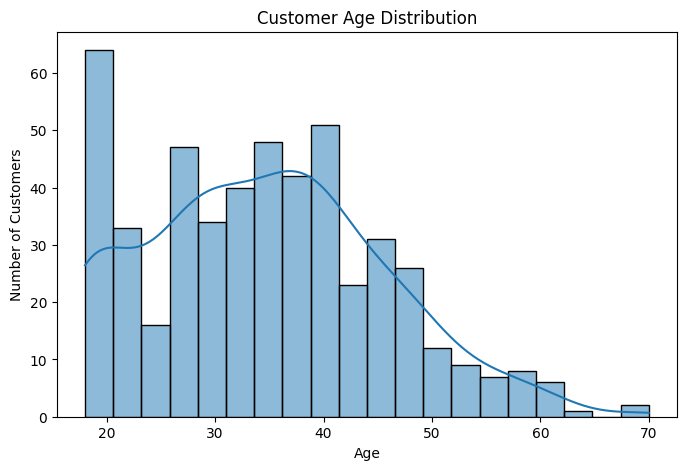

In [22]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Customer Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

# Gender Distribution

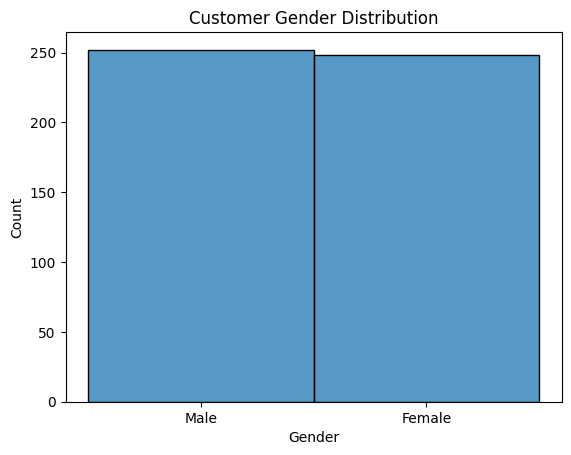

In [23]:
sns.histplot(data=df, x="Gender")

plt.title("Customer Gender Distribution")
plt.show()

# Total Spending Distribution

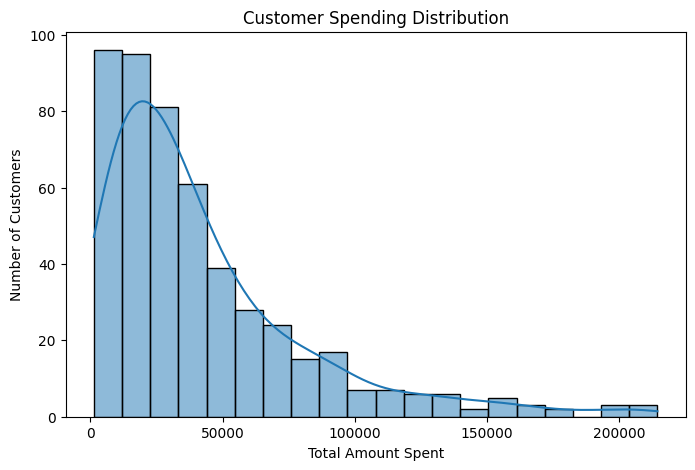

In [24]:
plt.figure(figsize=(8,5))

sns.histplot(df["Total_Amount"], bins=20, kde=True)

plt.title("Customer Spending Distribution")
plt.xlabel("Total Amount Spent")
plt.ylabel("Number of Customers")

plt.show()

# Purchase Frequency

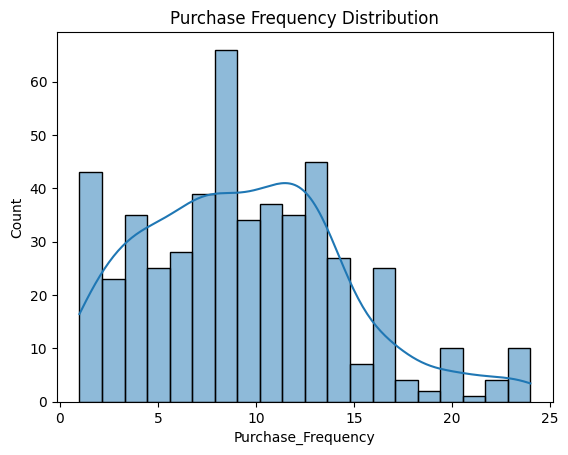

In [25]:
sns.histplot(df["Purchase_Frequency"], bins=20, kde=True)

plt.title("Purchase Frequency Distribution")
plt.show()

# Preferred Category

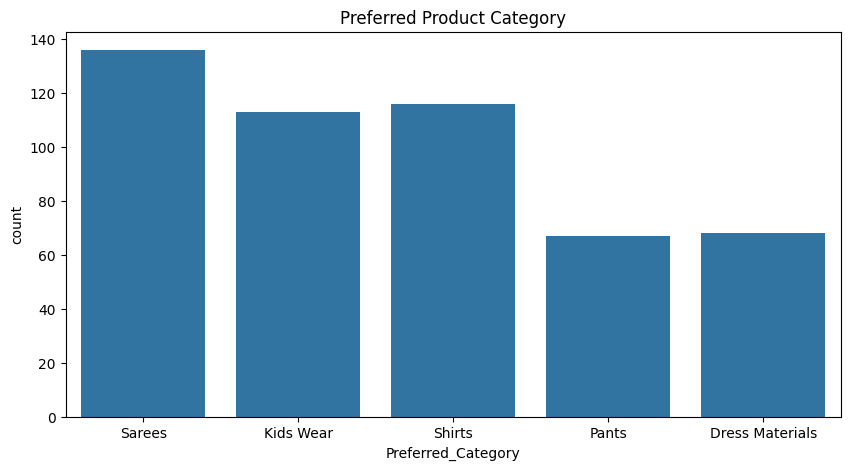

In [26]:
plt.figure(figsize=(10,5))

sns.countplot(data=df, x="Preferred_Category")

plt.xticks(rotation=0)

plt.title("Preferred Product Category")

plt.show()

# Membership Distribution

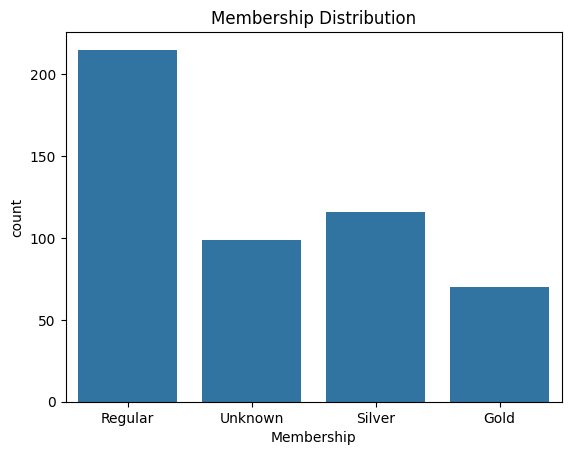

In [27]:
sns.countplot(data=df, x="Membership")

plt.title("Membership Distribution")

plt.show()

In [28]:
features = [
    "Age",
    "Purchase_Frequency",
    "Total_Purchases",
    "Total_Amount",
    "Average_Purchase",
    "Discount_Count",
    "Return_Count",
    "Days_Since_Purchase"
]

In [29]:
X = df[features]

In [30]:
X.head()

,Age,Purchase_Frequency,Total_Purchases,Total_Amount,Average_Purchase,Discount_Count,Return_Count,Days_Since_Purchase
0,28.0,8.0,19.0,40448.52,2128.87,3.0,0.0,119.0
1,18.0,9.0,20.0,39472.85,1973.64,3.0,1.0,72.0
2,30.0,2.0,4.0,6307.48,1576.87,3.0,1.0,165.0
3,46.0,5.0,7.0,7988.91,1141.27,9.0,1.0,68.0
4,41.0,5.0,10.0,18123.68,1812.37,2.0,1.0,34.0


In [31]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[-0.59173938, -0.27338745, -0.03440822, -0.04752365,  0.21709172,
        -0.41476303, -0.79236431,  0.37204476],
       [-1.50576376, -0.0781107 ,  0.05204459, -0.0723474 ,  0.02141636,
        -0.41476303,  0.43420583, -0.28930561],
       [-0.40893451, -1.44504793, -1.3312003 , -0.91616649, -0.47873253,
        -0.41476303,  0.43420583,  1.01932384],
       [ 1.0535045 , -0.85921769, -1.07184188, -0.87338624, -1.02782862,
         1.56343903,  0.43420583, -0.34559074],
       [ 0.59649231, -0.85921769, -0.81248347, -0.61552956, -0.18187273,
        -0.74446337,  0.43420583, -0.82401441]])

In [32]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

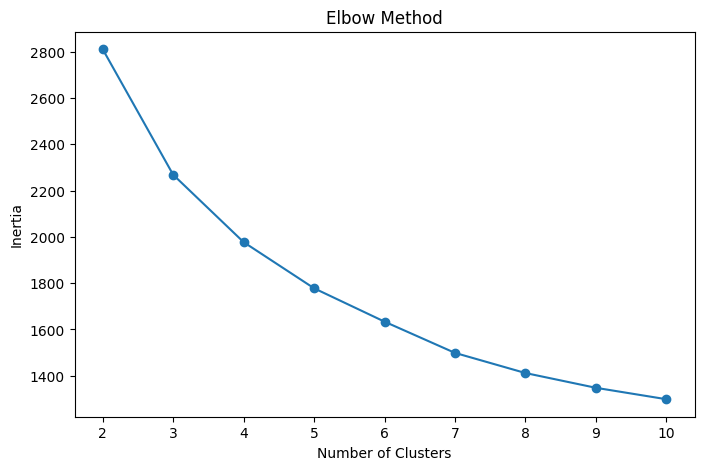

In [33]:
plt.figure(figsize=(8,5))

plt.plot(range(2,11), inertia, marker="o")

plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

In [34]:
silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(X_scaled, labels)

    silhouette_scores.append(score)

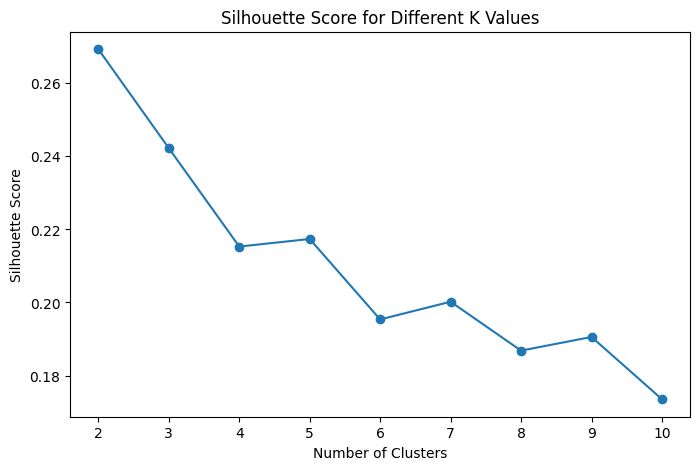

In [35]:
plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for Different K Values")

plt.show()

In [36]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(X_scaled)

In [37]:
df["Cluster"] = clusters
df.head()

,Customer_ID,Age,Gender,Purchase_Frequency,Total_Purchases,Total_Amount,Average_Purchase,Shirts,Sarees,Pants,Kids_Wear,Dress_Materials,Discount_Count,Return_Count,Days_Since_Purchase,Preferred_Category,Membership,Payment_Method,Cluster
0,C00001,28.0,Male,8.0,19.0,40448.52,2128.87,5.0,8.0,1.0,2.0,3.0,3.0,0.0,119.0,Sarees,Regular,UPI,3
1,C00002,18.0,Male,9.0,20.0,39472.85,1973.64,3.0,3.0,0.0,12.0,2.0,3.0,1.0,72.0,Kids Wear,Unknown,UPI,3
2,C00003,30.0,Female,2.0,4.0,6307.48,1576.87,0.0,2.0,0.0,2.0,0.0,3.0,1.0,165.0,Sarees,Regular,Cash,2
3,C00004,46.0,Male,5.0,7.0,7988.91,1141.27,1.0,4.0,0.0,1.0,1.0,9.0,1.0,68.0,Sarees,Silver,UPI,1
4,C00005,41.0,Male,5.0,10.0,18123.68,1812.37,4.0,2.0,1.0,2.0,1.0,2.0,1.0,34.0,Sarees,Unknown,UPI,3


In [38]:
cluster_summary = df.groupby("Cluster")[features].mean()

print(cluster_summary)

               Age  Purchase_Frequency  Total_Purchases   Total_Amount  \
Cluster                                                                  
0        33.263889           17.166667        36.986111  119983.934861   
1        37.751880            8.473684        17.586466   22172.023233   
2        35.105263            2.726316         5.463158    8485.745368   
3        32.430000           10.390000        20.890000   43821.619150   

         Average_Purchase  Discount_Count  Return_Count  Days_Since_Purchase  
Cluster                                                                       
0             3280.858611        2.000000      0.500000            40.263889  
1             1282.199098        7.977444      0.571429            91.458647  
2             1545.140737        1.936842      0.178947           194.252632  
3             2123.912450        3.700000      0.970000            63.815000  


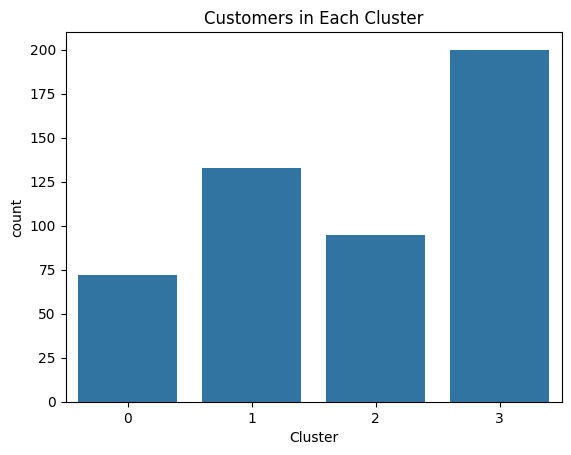

In [39]:
df["Cluster"].value_counts().sort_index()

sns.countplot(data=df, x="Cluster")

plt.title("Customers in Each Cluster")
plt.show()

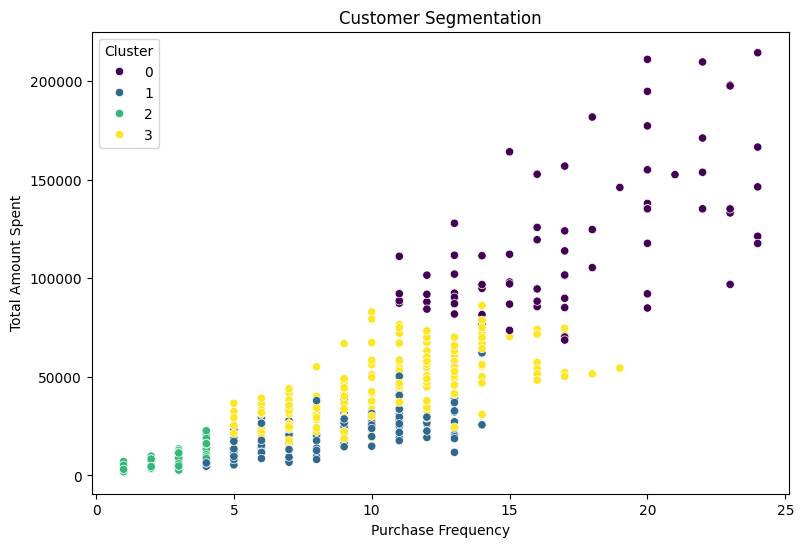

In [40]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=df,
    x="Purchase_Frequency",
    y="Total_Amount",
    hue="Cluster",
    palette="viridis"
)

plt.title("Customer Segmentation")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Amount Spent")

plt.show()

In [41]:
cluster_profile = df.groupby("Cluster").agg({
    "Age": "mean",
    "Purchase_Frequency": "mean",
    "Total_Purchases": "mean",
    "Total_Amount": "mean",
    "Average_Purchase": "mean",
    "Discount_Count": "mean",
    "Return_Count": "mean",
    "Days_Since_Purchase": "mean"
}).round(2)

print(cluster_profile)

           Age  Purchase_Frequency  Total_Purchases  Total_Amount  \
Cluster                                                             
0        33.26               17.17            36.99     119983.93   
1        37.75                8.47            17.59      22172.02   
2        35.11                2.73             5.46       8485.75   
3        32.43               10.39            20.89      43821.62   

         Average_Purchase  Discount_Count  Return_Count  Days_Since_Purchase  
Cluster                                                                       
0                 3280.86            2.00          0.50                40.26  
1                 1282.20            7.98          0.57                91.46  
2                 1545.14            1.94          0.18               194.25  
3                 2123.91            3.70          0.97                63.82  


In [42]:
df.groupby("Cluster")[
    ["Shirts", "Sarees", "Pants", "Kids_Wear", "Dress_Materials"]
].mean()

,Shirts,Sarees,Pants,Kids_Wear,Dress_Materials
Cluster,,,,,
0,7.736111,13.277778,5.597222,4.569444,5.805556
1,4.368421,4.022556,3.654135,3.097744,2.443609
2,1.242105,1.368421,1.042105,1.126316,0.684211
3,4.635000,5.830000,3.290000,4.425000,2.710000


In [43]:
df.to_csv(
    "customer_segmentation_results.csv",
    index=False
)

In [44]:
df["Cluster"] = clusters

In [45]:
df.to_csv("customer_segmentation_results.csv", index=False)

In [46]:
print(df["Cluster"].value_counts().sort_index())
print(df.groupby("Cluster")[features].mean().round(2))

Cluster
0     72
1    133
2     95
3    200
Name: count, dtype: int64
           Age  Purchase_Frequency  Total_Purchases  Total_Amount  \
Cluster                                                             
0        33.26               17.17            36.99     119983.93   
1        37.75                8.47            17.59      22172.02   
2        35.11                2.73             5.46       8485.75   
3        32.43               10.39            20.89      43821.62   

         Average_Purchase  Discount_Count  Return_Count  Days_Since_Purchase  
Cluster                                                                       
0                 3280.86            2.00          0.50                40.26  
1                 1282.20            7.98          0.57                91.46  
2                 1545.14            1.94          0.18               194.25  
3                 2123.91            3.70          0.97                63.82  


In [47]:
product_columns = [
    "Shirts",
    "Sarees",
    "Pants",
    "Kids_Wear",
    "Dress_Materials"
]

product_profile = df.groupby("Cluster")[product_columns].mean().round(2)

print(product_profile)

membership_profile = pd.crosstab(
    df["Cluster"],
    df["Membership"],
    normalize="index"
) * 100

print(membership_profile.round(2))

         Shirts  Sarees  Pants  Kids_Wear  Dress_Materials
Cluster                                                   
0          7.74   13.28   5.60       4.57             5.81
1          4.37    4.02   3.65       3.10             2.44
2          1.24    1.37   1.04       1.13             0.68
3          4.64    5.83   3.29       4.42             2.71
Membership   Gold  Regular  Silver  Unknown
Cluster                                    
0            8.33    37.50   30.56    23.61
1           17.29    42.11   22.56    18.05
2           14.74    43.16   25.26    16.84
3           13.50    45.50   20.00    21.00


In [48]:
final_silhouette = silhouette_score(
    X_scaled,
    df["Cluster"]
)

print("Final Silhouette Score:", round(final_silhouette, 3))

Final Silhouette Score: 0.215


In [49]:
for k, score in zip(range(2, 11), silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.3f}")

K = 2: Silhouette Score = 0.269
K = 3: Silhouette Score = 0.242
K = 4: Silhouette Score = 0.215
K = 5: Silhouette Score = 0.217
K = 6: Silhouette Score = 0.195
K = 7: Silhouette Score = 0.200
K = 8: Silhouette Score = 0.187
K = 9: Silhouette Score = 0.191
K = 10: Silhouette Score = 0.174


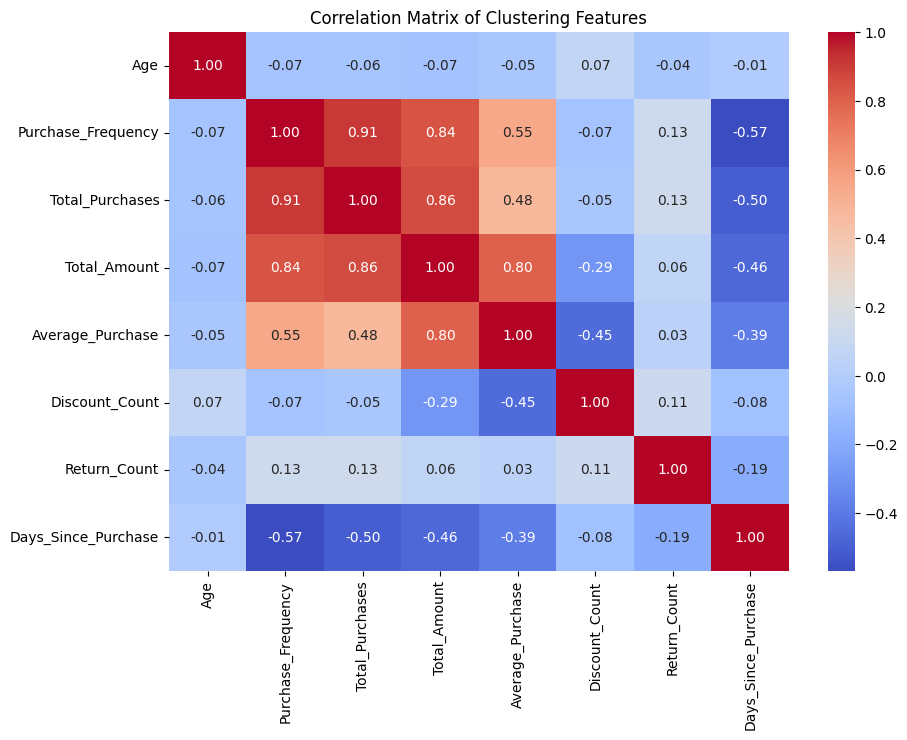

In [50]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df[features].corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix of Clustering Features")

plt.show()

In [51]:
behavior_features = [
    "Purchase_Frequency",
    "Total_Amount",
    "Discount_Count",
    "Return_Count",
    "Days_Since_Purchase"
]

X_behavior = df[behavior_features]

In [52]:
from sklearn.preprocessing import StandardScaler

scaler_behavior = StandardScaler()

X_behavior_scaled = scaler_behavior.fit_transform(X_behavior)

In [53]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

behavior_silhouette_scores = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(X_behavior_scaled)

    score = silhouette_score(
        X_behavior_scaled,
        labels
    )

    behavior_silhouette_scores.append(score)

for k, score in zip(range(2, 11), behavior_silhouette_scores):
    print(f"K = {k}: Silhouette Score = {score:.3f}")

K = 2: Silhouette Score = 0.265
K = 3: Silhouette Score = 0.290
K = 4: Silhouette Score = 0.283
K = 5: Silhouette Score = 0.291
K = 6: Silhouette Score = 0.272
K = 7: Silhouette Score = 0.249
K = 8: Silhouette Score = 0.257
K = 9: Silhouette Score = 0.262
K = 10: Silhouette Score = 0.257


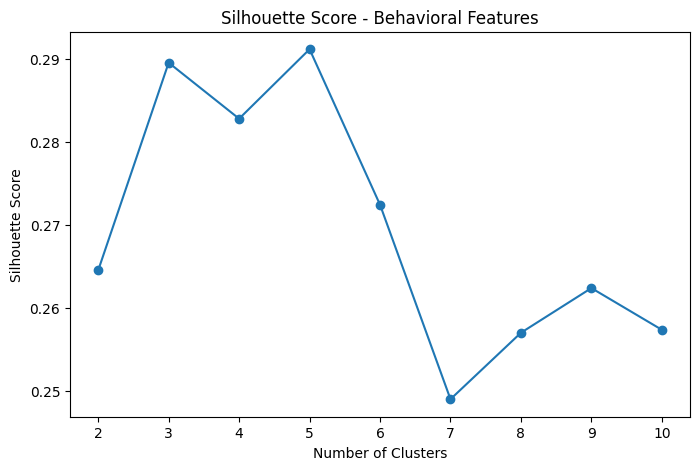

In [54]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(2, 11),
    behavior_silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score - Behavioral Features")

plt.show()

In [55]:
kmeans_final = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

final_labels = kmeans_final.fit_predict(X_behavior_scaled)

df["Final_Cluster"] = final_labels

In [56]:
print(df["Final_Cluster"].value_counts().sort_index())

Final_Cluster
0    113
1     69
2     90
3     49
4    179
Name: count, dtype: int64


In [57]:
final_cluster_profile = df.groupby("Final_Cluster").agg(
    Customer_Count=("Customer_ID", "count"),
    Avg_Purchase_Frequency=("Purchase_Frequency", "mean"),
    Avg_Total_Amount=("Total_Amount", "mean"),
    Avg_Discount_Count=("Discount_Count", "mean"),
    Avg_Return_Count=("Return_Count", "mean"),
    Avg_Days_Since_Purchase=("Days_Since_Purchase", "mean")
).round(2)

print(final_cluster_profile)

               Customer_Count  Avg_Purchase_Frequency  Avg_Total_Amount  \
Final_Cluster                                                             
0                         113                    8.12          22067.17   
1                          69                   10.28          43677.23   
2                          90                    2.57           8178.82   
3                          49                   18.71         134435.66   
4                         179                   10.75          46521.97   

               Avg_Discount_Count  Avg_Return_Count  Avg_Days_Since_Purchase  
Final_Cluster                                                                 
0                            8.42              0.52                    96.75  
1                            4.26              2.20                    68.03  
2                            1.89              0.14                   198.92  
3                            1.57              0.35                    31.76  


In [58]:
final_product_profile = df.groupby("Final_Cluster")[
    product_columns
].mean().round(2)

print(final_product_profile)

               Shirts  Sarees  Pants  Kids_Wear  Dress_Materials
Final_Cluster                                                   
0                4.14    3.86   3.48       3.12             2.27
1                4.46    5.81   3.49       4.91             2.88
2                1.17    1.34   1.04       1.11             0.64
3                8.16   15.41   6.41       3.29             6.57
4                5.04    6.00   3.37       4.36             2.88


In [59]:
final_membership_profile = pd.crosstab(
    df["Final_Cluster"],
    df["Membership"],
    normalize="index"
) * 100

print(final_membership_profile.round(2))

Membership      Gold  Regular  Silver  Unknown
Final_Cluster                                 
0              17.70    39.82   25.66    16.81
1              20.29    46.38   20.29    13.04
2              15.56    43.33   24.44    16.67
3              10.20    36.73   24.49    28.57
4               9.50    45.25   21.79    23.46


In [60]:
final_silhouette = silhouette_score(
    X_behavior_scaled,
    df["Final_Cluster"]
)

print("Final Silhouette Score:", round(final_silhouette, 3))

Final Silhouette Score: 0.291


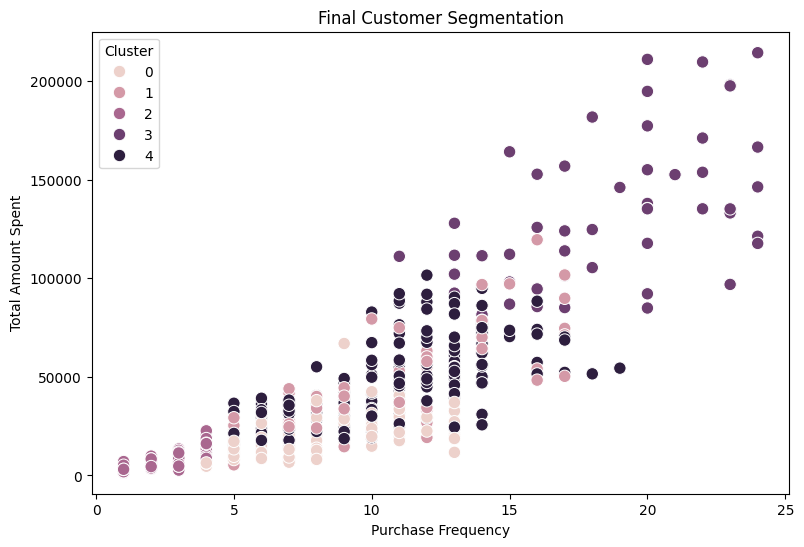

In [61]:
plt.figure(figsize=(9, 6))

sns.scatterplot(
    data=df,
    x="Purchase_Frequency",
    y="Total_Amount",
    hue="Final_Cluster",
    s=80
)

plt.title("Final Customer Segmentation")
plt.xlabel("Purchase Frequency")
plt.ylabel("Total Amount Spent")
plt.legend(title="Cluster")

plt.show()

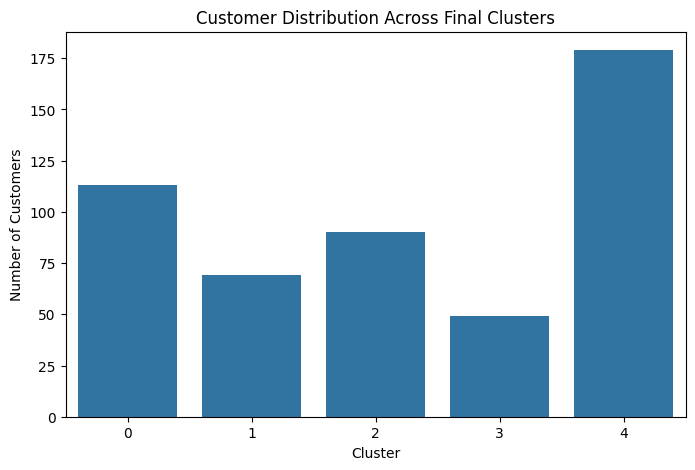

In [62]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Final_Cluster"
)

plt.title("Customer Distribution Across Final Clusters")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")

plt.show()

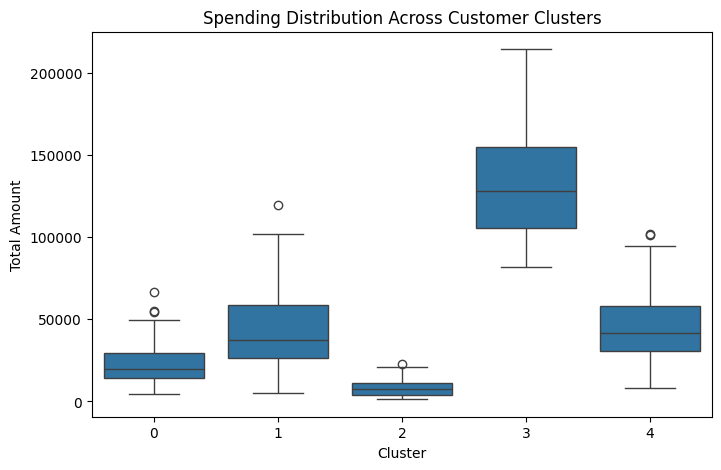

In [63]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Final_Cluster",
    y="Total_Amount"
)

plt.title("Spending Distribution Across Customer Clusters")
plt.xlabel("Cluster")
plt.ylabel("Total Amount")

plt.show()

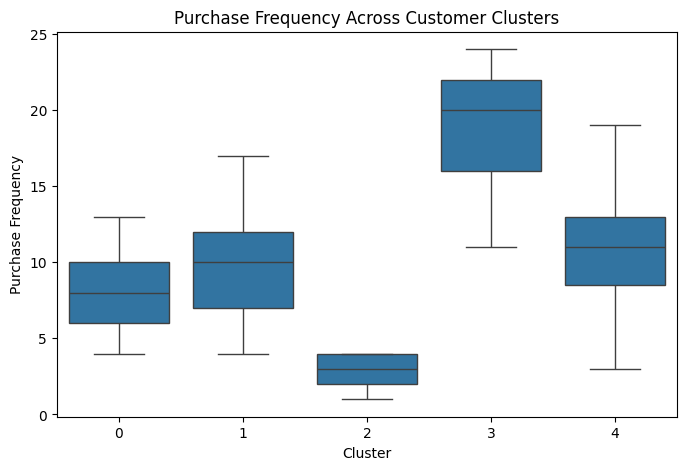

In [64]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Final_Cluster",
    y="Purchase_Frequency"
)

plt.title("Purchase Frequency Across Customer Clusters")
plt.xlabel("Cluster")
plt.ylabel("Purchase Frequency")

plt.show()

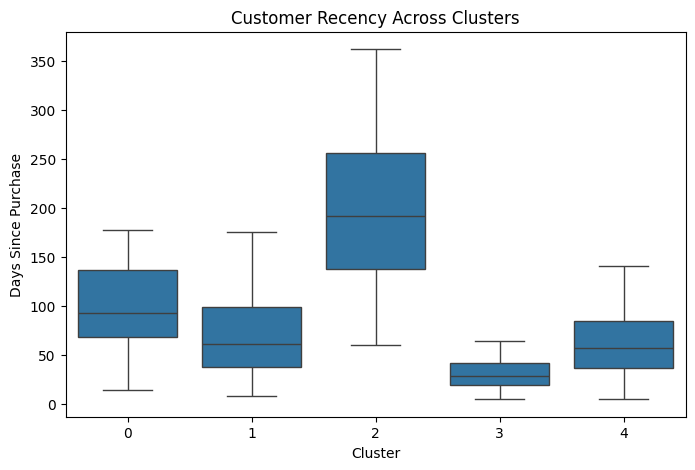

In [65]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Final_Cluster",
    y="Days_Since_Purchase"
)

plt.title("Customer Recency Across Clusters")
plt.xlabel("Cluster")
plt.ylabel("Days Since Purchase")

plt.show()

In [66]:
df.to_csv(
    "customer_segmentation_final.csv",
    index=False
)

print("Final customer segmentation dataset saved successfully.")

Final customer segmentation dataset saved successfully.


In [67]:
final_output = df.copy()

final_output.to_csv(
    "customer_segmentation_final.csv",
    index=False
)

print("Final dataset saved successfully!")
print(final_output.shape)
print(final_output["Final_Cluster"].value_counts().sort_index())

Final dataset saved successfully!
(500, 20)
Final_Cluster
0    113
1     69
2     90
3     49
4    179
Name: count, dtype: int64


In [68]:
check = pd.read_csv("customer_segmentation_final.csv")

print(check.shape)
print(check.columns)
print(check["Final_Cluster"].value_counts().sort_index())

(500, 20)
Index(['Customer_ID', 'Age', 'Gender', 'Purchase_Frequency', 'Total_Purchases',
       'Total_Amount', 'Average_Purchase', 'Shirts', 'Sarees', 'Pants',
       'Kids_Wear', 'Dress_Materials', 'Discount_Count', 'Return_Count',
       'Days_Since_Purchase', 'Preferred_Category', 'Membership',
       'Payment_Method', 'Cluster', 'Final_Cluster'],
      dtype='object')
Final_Cluster
0    113
1     69
2     90
3     49
4    179
Name: count, dtype: int64


In [69]:
final_output = df.copy()

final_output = final_output.rename(
    columns={"Final_Cluster": "Customer_Segment"}
)

final_output.to_csv(
    "customer_segmentation_final.csv",
    index=False
)

print(final_output["Customer_Segment"].value_counts().sort_index())

Customer_Segment
0    113
1     69
2     90
3     49
4    179
Name: count, dtype: int64


In [70]:
final_output = df.copy()

# Remove the old K=4 cluster
final_output = final_output.drop(columns=["Cluster"])

# Rename final cluster
final_output = final_output.rename(
    columns={"Final_Cluster": "Customer_Segment"}
)

# Save final dataset
final_output.to_csv(
    "customer_segmentation_final.csv",
    index=False
)

print(final_output.shape)
print(final_output.columns)
print(final_output["Customer_Segment"].value_counts().sort_index())

(500, 19)
Index(['Customer_ID', 'Age', 'Gender', 'Purchase_Frequency', 'Total_Purchases',
       'Total_Amount', 'Average_Purchase', 'Shirts', 'Sarees', 'Pants',
       'Kids_Wear', 'Dress_Materials', 'Discount_Count', 'Return_Count',
       'Days_Since_Purchase', 'Preferred_Category', 'Membership',
       'Payment_Method', 'Customer_Segment'],
      dtype='object')
Customer_Segment
0    113
1     69
2     90
3     49
4    179
Name: count, dtype: int64
